# Mutual Fund Performance Analytics
This notebook implements the complete Performance Analytics module for the Mutual Fund Analytics Platform.
It loads and validates raw datasets, computes daily returns, CAGR, Sharpe and Sortino ratios, Alpha and Beta against Nifty 100, maximum drawdowns, tracking errors, and builds a composite fund scorecard.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, skew, kurtosis

# Set style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Required Datasets and Validate
We load and validate the following raw datasets:
- **Fund Master** (`01_fund_master.csv`)
- **NAV History** (`02_nav_history.csv`)
- **Scheme Performance** (`07_scheme_performance.csv`)
- **Benchmark Indices** (`10_benchmark_indices.csv`)

We perform checking for missing values, duplicates, verify AMFI codes, ensure benchmark dates align, and validate numeric columns.

In [2]:
raw_dir = '../data/raw'

fund_master = pd.read_csv(os.path.join(raw_dir, '01_fund_master.csv'))
nav_history = pd.read_csv(os.path.join(raw_dir, '02_nav_history.csv'))
scheme_performance = pd.read_csv(os.path.join(raw_dir, '07_scheme_performance.csv'))
benchmark_indices = pd.read_csv(os.path.join(raw_dir, '10_benchmark_indices.csv'))

print("--- Dataset Shapes ---")
print(f"Fund Master: {fund_master.shape}")
print(f"NAV History: {nav_history.shape}")
print(f"Scheme Performance: {scheme_performance.shape}")
print(f"Benchmark Indices: {benchmark_indices.shape}\n")

# Missing values
print("--- Missing Values Check ---")
print(f"Fund Master missing values:\n{fund_master.isnull().sum()}\n")

# Remove duplicates
fund_master = fund_master.drop_duplicates()
nav_history = nav_history.drop_duplicates()
scheme_performance = scheme_performance.drop_duplicates()
benchmark_indices = benchmark_indices.drop_duplicates()

# Date conversions
nav_history['date'] = pd.to_datetime(nav_history['date'])
benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'])
fund_master['launch_date'] = pd.to_datetime(fund_master['launch_date'])

# Verify AMFI codes
valid_amfi = set(fund_master['amfi_code'])
nav_history = nav_history[nav_history['amfi_code'].isin(valid_amfi)]
print(f"Verified {len(valid_amfi)} AMFI codes in Fund Master.")

# Validate numeric columns
nav_history['nav'] = pd.to_numeric(nav_history['nav'], errors='coerce')
nav_history = nav_history.dropna(subset=['nav'])
benchmark_indices['close_value'] = pd.to_numeric(benchmark_indices['close_value'], errors='coerce')
benchmark_indices = benchmark_indices.dropna(subset=['close_value'])

# Sort
nav_history = nav_history.sort_values(['amfi_code', 'date']).reset_index(drop=True)
benchmark_indices = benchmark_indices.sort_values(['index_name', 'date']).reset_index(drop=True)
print("Validation and sorting complete.")

--- Dataset Shapes ---
Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark Indices: (8050, 3)

--- Missing Values Check ---
Fund Master missing values:
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

Verified 40 AMFI codes in Fund Master.
Validation and sorting complete.


## 2. Compute Daily Returns
We calculate the daily returns for each mutual fund scheme using:
$$daily\_return = \frac{NAV_t}{NAV_{t-1}} - 1$$
We calculate returns separately for each AMFI code, sort by date before calculation, remove the first NaN return, flag extreme outliers ($> \pm 20\%$), and print descriptive statistics.

Extreme outliers (> ±20% daily return): 0

--- Descriptive Statistics for Daily Returns ---
Mean: 0.000631
Median: 0.000340
Standard Deviation: 0.010290
Minimum: -0.058102
Maximum: 0.064713
Skewness: 0.042676
Kurtosis: 1.367033


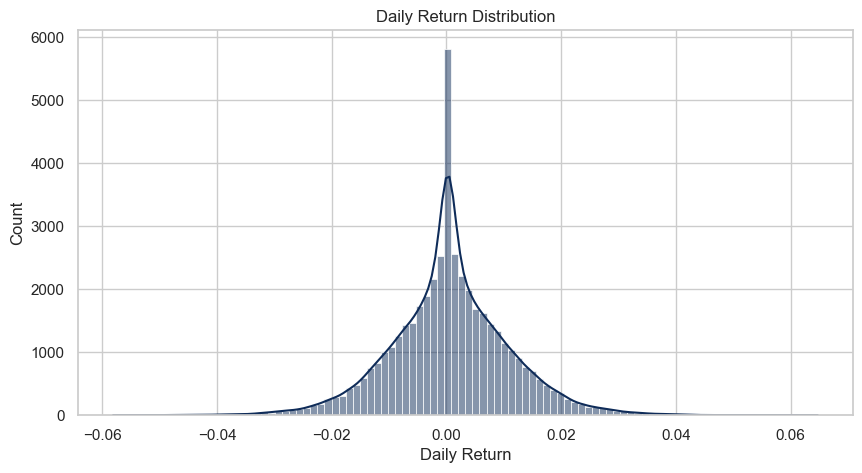

In [3]:
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()
nav_history_clean = nav_history.dropna(subset=['daily_return']).copy()

# Outliers
outliers = nav_history_clean[nav_history_clean['daily_return'].abs() > 0.20]
print(f"Extreme outliers (> ±20% daily return): {len(outliers)}")

# Stats
print("\n--- Descriptive Statistics for Daily Returns ---")
stats = {
    'Mean': nav_history_clean['daily_return'].mean(),
    'Median': nav_history_clean['daily_return'].median(),
    'Standard Deviation': nav_history_clean['daily_return'].std(),
    'Minimum': nav_history_clean['daily_return'].min(),
    'Maximum': nav_history_clean['daily_return'].max(),
    'Skewness': skew(nav_history_clean['daily_return']),
    'Kurtosis': kurtosis(nav_history_clean['daily_return'])
}
for k, v in stats.items():
    print(f"{k}: {v:.6f}")

# Save to CSV
nav_history_clean.to_csv('../data/processed/returns_computed.csv', index=False)

# Plotting
plt.figure(figsize=(10, 5))
sns.histplot(nav_history_clean['daily_return'], bins=100, kde=True, color='#0F2C59')
plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.show()

## 3. Compute CAGR (1, 3, 5 Years)
CAGR (Compound Annual Growth Rate) is computed using:
$$CAGR = \left(\frac{Ending\ NAV}{Beginning\ NAV}\right)^{\frac{1}{Number\ of\ Years}} - 1$$
We handle insufficient history gracefully and ignore incomplete periods. Values are rounded to four decimal places.

In [4]:
cagr_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    group = group.sort_values('date')
    ending_date = group['date'].max()
    ending_nav = group['nav'].iloc[-1]
    
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    
    def get_cagr_n_years(years):
        target_date = ending_date - pd.DateOffset(years=years)
        idx = (group['date'] - target_date).abs().idxmin()
        row = group.loc[idx]
        if abs((row['date'] - target_date).days) > 7:
            return np.nan
        return (ending_nav / row['nav']) ** (1.0 / years) - 1.0
        
    cagr_1 = get_cagr_n_years(1)
    cagr_3 = get_cagr_n_years(3)
    cagr_5 = get_cagr_n_years(5)
    
    cagr_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'fund_house': fund_info['fund_house'],
        'category': fund_info['category'],
        '1-Year CAGR': round(cagr_1, 4) if not np.isnan(cagr_1) else np.nan,
        '3-Year CAGR': round(cagr_3, 4) if not np.isnan(cagr_3) else np.nan,
        '5-Year CAGR': round(cagr_5, 4) if not np.isnan(cagr_5) else np.nan
    })
    
df_cagr = pd.DataFrame(cagr_list).sort_values('5-Year CAGR', ascending=False, na_position='last')
df_cagr.to_csv('../data/processed/cagr_report.csv', index=False)
print("CAGR Report preview:")
df_cagr.head(10)

CAGR Report preview:


,amfi_code,scheme_name,fund_house,category,1-Year CAGR,3-Year CAGR,5-Year CAGR
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.0222,0.0129,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.0370,0.0392,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.5323,0.3244,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.4792,0.2897,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.2399,-0.0415,NaN
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,0.0724,0.0632,NaN
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,0.2021,0.1967,NaN
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.1680,-0.0077,NaN
8,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,0.1358,0.2556,NaN
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.3398,0.2265,NaN


## 4. Compute Sharpe Ratio
The Sharpe Ratio measures the excess return per unit of standard deviation (volatility):
$$Sharpe = \frac{R_p - R_f}{\sigma_p}$$
We use a risk-free rate ($R_f$) of $6.5\%$. Volatility is annualized using daily returns standard deviation $\times \sqrt{252}$.

Top 5 Sharpe Ratios:
   amfi_code                                    scheme_name  \
0     148567  Mirae Asset Large Cap Fund - Regular - Growth   
1     120843         Kotak Flexicap Fund - Regular - Growth   
2     148569  Mirae Asset Tax Saver Fund - Regular - Growth   
3     119551      SBI Bluechip Fund - Regular Plan - Growth   
4     120505       ICICI Pru Midcap Fund - Regular - Growth   

   annualized_return  annualized_volatility  sharpe_ratio  rank  
0           0.270566               0.141875      1.448922   1.0  
1           0.272602               0.158801      1.307313   2.0  
2           0.283262               0.176663      1.235468   3.0  
3           0.231033               0.137355      1.208793   4.0  
4           0.292653               0.192826      1.180615   5.0  

Bottom 5 Sharpe Ratios:
    amfi_code                                        scheme_name  \
35     102886                UTI Mid Cap Fund - Regular - Growth   
36     119120       SBI Magnum Gilt Fund - 

/var/folders/ql/_d3lq9h100gfgdbxjdg224yc0000gn/T/ipykernel_64147/995390758.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sharpe_ratio', y='scheme_name', data=df_sharpe.head(10), palette='crest')


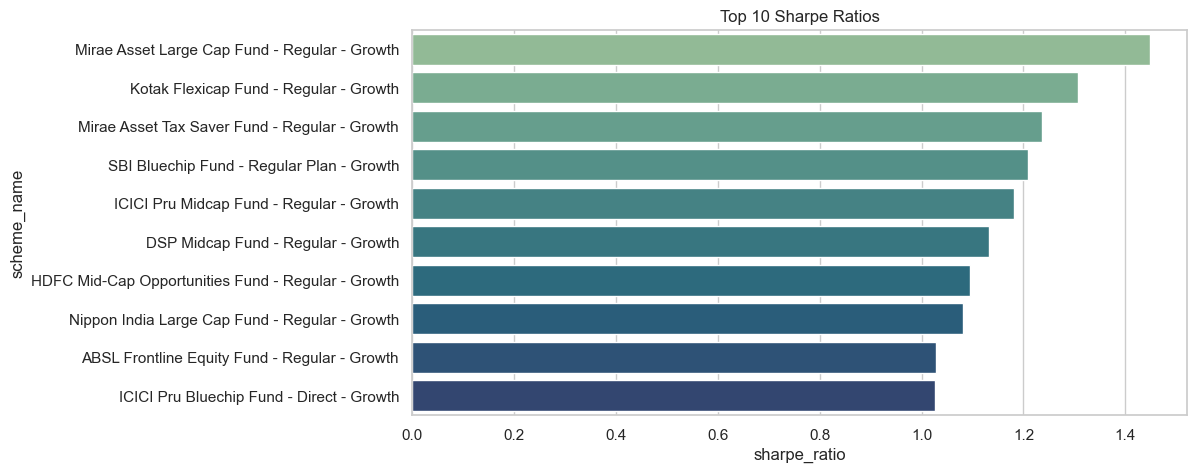

In [5]:
rf = 0.065
sharpe_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    returns = group['daily_return'].values
    ann_return = np.mean(returns) * 252
    ann_vol = np.std(returns) * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan
    
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    sharpe_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'annualized_return': ann_return,
        'annualized_volatility': ann_vol,
        'sharpe_ratio': sharpe
    })
    
df_sharpe = pd.DataFrame(sharpe_list).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
df_sharpe['rank'] = df_sharpe['sharpe_ratio'].rank(ascending=False, method='min')
df_sharpe.to_csv('../data/processed/sharpe_values.csv', index=False)

print("Top 5 Sharpe Ratios:")
print(df_sharpe.head(5))
print("\nBottom 5 Sharpe Ratios:")
print(df_sharpe.tail(5))

# Top 10 Sharpe plot
plt.figure(figsize=(10, 5))
sns.barplot(x='sharpe_ratio', y='scheme_name', data=df_sharpe.head(10), palette='crest')
plt.title('Top 10 Sharpe Ratios')
plt.show()

## 5. Compute Sortino Ratio
Sortino ratio differs from Sharpe ratio by only considering downside standard deviation:
$$Sortino = \frac{R_p - R_f}{\sigma_d}$$
We use only negative daily return observations to compute downside standard deviation, and annualize it.

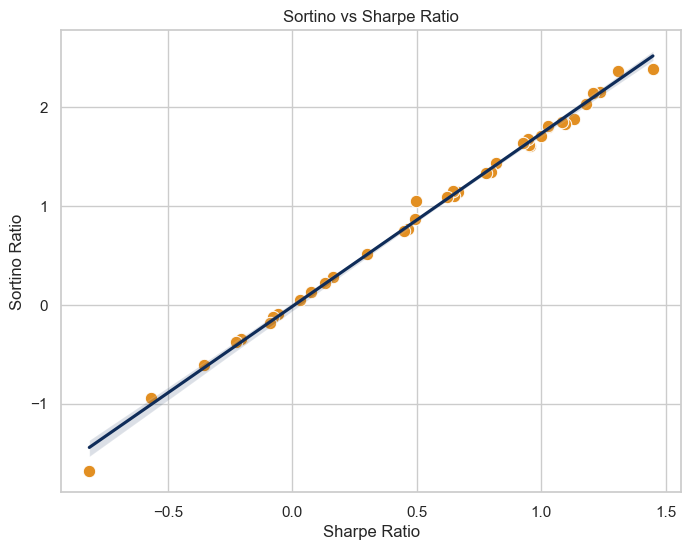

In [6]:
sortino_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    returns = group['daily_return'].values
    ann_return = np.mean(returns) * 252
    neg_returns = returns[returns < 0]
    downside_vol = np.std(neg_returns) * np.sqrt(252) if len(neg_returns) > 1 else np.nan
    sortino = (ann_return - rf) / downside_vol if downside_vol > 0 else np.nan
    
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    sortino_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'downside_volatility': downside_vol,
        'sortino_ratio': sortino
    })
    
df_sortino = pd.DataFrame(sortino_list).sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
df_sortino.to_csv('../data/processed/sortino_values.csv', index=False)

# Comparison Scatter Plot
merged = pd.merge(df_sharpe[['amfi_code', 'sharpe_ratio']], df_sortino[['amfi_code', 'sortino_ratio']], on='amfi_code')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sharpe_ratio', y='sortino_ratio', data=merged, color='#E28F22', s=80)
sns.regplot(x='sharpe_ratio', y='sortino_ratio', data=merged, scatter=False, color='#0F2C59')
plt.title('Sortino vs Sharpe Ratio')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Sortino Ratio')
plt.show()

## 6. Compute Alpha and Beta
We calculate Alpha and Beta against the Nifty 100 benchmark index using linear regression:
$$Fund\ Return = Alpha + Beta \times Benchmark\ Return$$
Alpha is annualized: $Annual\ Alpha = intercept \times 252$.

In [7]:
nifty100 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY100'].copy()
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bench_return'])

ab_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    merged_ret = pd.merge(group[['date', 'daily_return']], nifty100[['date', 'bench_return']], on='date')
    if len(merged_ret) < 30:
        continue
    slope, intercept, r_val, p_val, std_err = linregress(merged_ret['bench_return'], merged_ret['daily_return'])
    
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    ab_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'alpha': intercept * 252,
        'beta': slope,
        'r_value': r_val,
        'p_value': p_val,
        'standard_error': std_err
    })
    
df_ab = pd.DataFrame(ab_list).sort_values('alpha', ascending=False).reset_index(drop=True)
df_ab.to_csv('../data/processed/alpha_beta.csv', index=False)
df_ab.head(5)

,amfi_code,scheme_name,alpha,beta,r_value,p_value,standard_error
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,-0.011892,0.687179,0.057589
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,0.005944,0.840494,0.056904
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,0.000367,0.990090,0.044192
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,0.013225,0.654295,0.040485
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,-0.018522,0.530528,0.036388


## 7. Compute Maximum Drawdown
Drawdown is calculated as:
$$Drawdown = \frac{NAV_t}{Running\ Max} - 1$$
Maximum Drawdown is the lowest value of Drawdown. We also identify peak start dates, trough end dates, recovery dates, and duration.

In [8]:
dd_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    group = group.sort_values('date').reset_index(drop=True)
    dates = group['date'].values
    navs = group['nav'].values
    
    running_max = np.maximum.accumulate(navs)
    drawdowns = navs / running_max - 1.0
    max_dd = np.min(drawdowns)
    
    if max_dd >= 0:
        dd_list.append({
            'amfi_code': code, 'scheme_name': group['amfi_code'].iloc[0], 'max_drawdown': 0.0,
            'start_date': np.nan, 'end_date': np.nan, 'recovery_date': np.nan, 'duration_days': 0
        })
        continue
        
    trough_idx = np.argmin(drawdowns)
    trough_date = dates[trough_idx]
    peak_val = running_max[trough_idx]
    peak_idx = np.where(navs[:trough_idx+1] == peak_val)[0][0]
    peak_date = dates[peak_idx]
    
    recovery_idx_list = np.where((dates > trough_date) & (navs >= peak_val))[0]
    if len(recovery_idx_list) > 0:
        rec_date = pd.to_datetime(dates[recovery_idx_list[0]]).strftime('%Y-%m-%d')
        duration = (pd.to_datetime(rec_date) - pd.to_datetime(peak_date)).days
    else:
        rec_date = "Not Recovered"
        duration = (pd.to_datetime(dates[-1]) - pd.to_datetime(peak_date)).days
        
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    dd_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'max_drawdown': max_dd,
        'start_date': pd.to_datetime(peak_date).strftime('%Y-%m-%d'),
        'end_date': pd.to_datetime(trough_date).strftime('%Y-%m-%d'),
        'recovery_date': rec_date,
        'duration_days': duration
    })
    
df_dd = pd.DataFrame(dd_list).sort_values('max_drawdown').reset_index(drop=True)
df_dd.to_csv('../data/processed/max_drawdown.csv', index=False)
df_dd.head(5)

,amfi_code,scheme_name,max_drawdown,start_date,end_date,recovery_date,duration_days
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2023-01-17,2025-10-28,Not Recovered,1228
1,119095,Axis Small Cap Fund - Regular - Growth,-0.516778,2025-05-22,2026-05-11,Not Recovered,372
2,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11,Not Recovered,554
3,149324,DSP Small Cap Fund - Regular - Growth,-0.311719,2024-05-03,2025-01-03,2025-06-13,406
4,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2024-08-28,2025-05-14,2025-09-29,397


## 8. Build Composite Fund Scorecard
The composite score (0-100) is built using a weighted ranking:
- **30%**: 3-Year CAGR Rank
- **25%**: Sharpe Rank
- **20%**: Alpha Rank
- **15%**: Expense Ratio Rank (inverse)
- **10%**: Max Drawdown Rank (inverse)

In [9]:
df_m = df_cagr[['amfi_code', '3-Year CAGR', 'fund_house', 'category', 'scheme_name']]
df_m = pd.merge(df_m, df_sharpe[['amfi_code', 'sharpe_ratio']], on='amfi_code')
df_m = pd.merge(df_m, df_ab[['amfi_code', 'alpha']], on='amfi_code')
df_m = pd.merge(df_m, df_dd[['amfi_code', 'max_drawdown']], on='amfi_code')
df_m = pd.merge(df_m, fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

df_m['rank_return'] = df_m['3-Year CAGR'].rank(pct=True) * 100
df_m['rank_sharpe'] = df_m['sharpe_ratio'].rank(pct=True) * 100
df_m['rank_alpha'] = df_m['alpha'].rank(pct=True) * 100
df_m['rank_expense'] = df_m['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
df_m['rank_drawdown'] = df_m['max_drawdown'].rank(pct=True) * 100

df_m['composite_score'] = (
    0.30 * df_m['rank_return'] +
    0.25 * df_m['rank_sharpe'] +
    0.20 * df_m['rank_alpha'] +
    0.15 * df_m['rank_expense'] +
    0.10 * df_m['rank_drawdown']
)

df_m = df_m.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_m['overall_rank'] = df_m['composite_score'].rank(ascending=False, method='min').astype(int)

def assign_grade(score):
    if score >= 80: return 'A+'
    elif score >= 65: return 'A'
    elif score >= 50: return 'B'
    elif score >= 35: return 'C'
    else: return 'D'

df_m['performance_grade'] = df_m['composite_score'].apply(assign_grade)
df_m.to_csv('../data/processed/fund_scorecard.csv', index=False)
df_m[['scheme_name', 'composite_score', 'overall_rank', 'performance_grade']].head(10)

,scheme_name,composite_score,overall_rank,performance_grade
0,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,1,A+
1,ICICI Pru Midcap Fund - Regular - Growth,82.2500,2,A+
2,Kotak Flexicap Fund - Regular - Growth,82.0000,3,A+
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,4,A+
4,ICICI Pru Bluechip Fund - Direct - Growth,80.0000,5,A+
5,Axis Midcap Fund - Regular - Growth,77.0000,6,A
6,SBI Bluechip Fund - Regular Plan - Growth,74.8125,7,A
7,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,8,A
8,ABSL Frontline Equity Fund - Regular - Growth,68.1875,9,A
9,SBI Small Cap Fund - Regular Plan - Growth,67.3750,10,A


## 9. Benchmark Comparison
We compare the Top 5 highest-scoring funds against **Nifty 50** and **Nifty 100** benchmarks over the latest available 3-year period. Series are normalized to 100 at starting date.

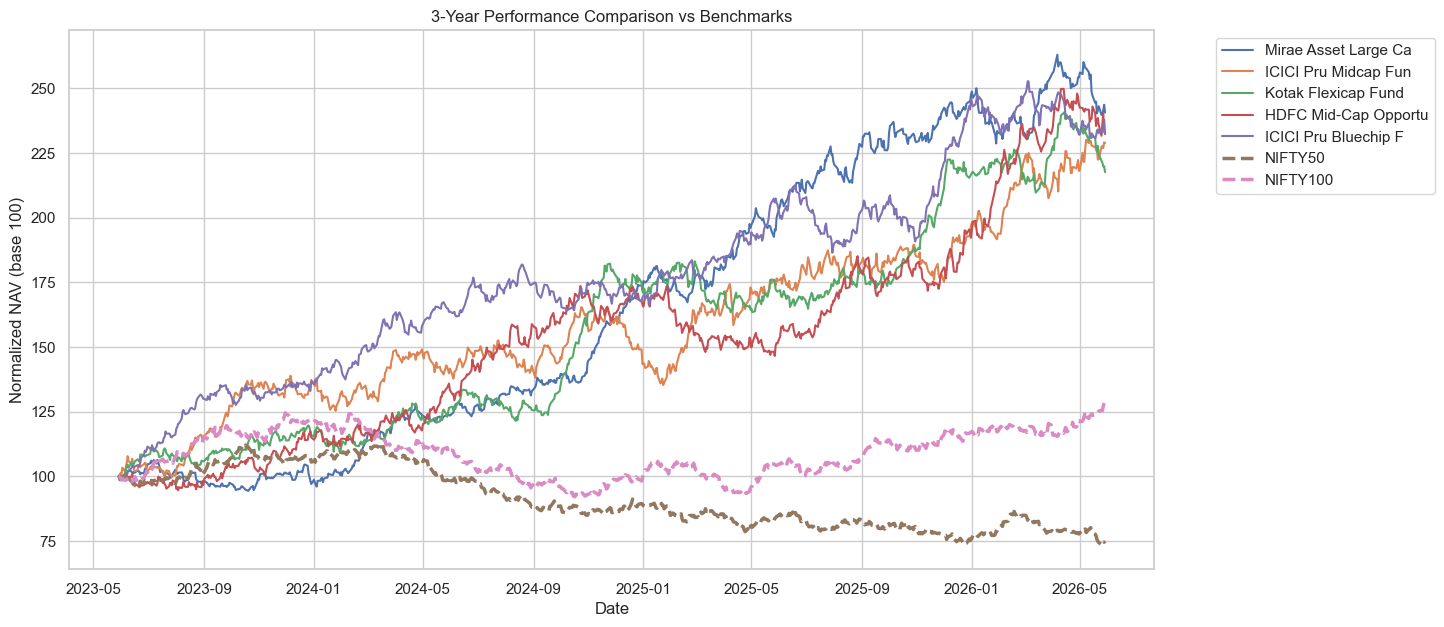

In [10]:
top_5_codes = df_m['amfi_code'].head(5).values
latest_date = nav_history_clean['date'].max()
start_date = latest_date - pd.DateOffset(years=3)

plt.figure(figsize=(14, 7))
for code in top_5_codes:
    sub = nav_history_clean[(nav_history_clean['amfi_code'] == code) & (nav_history_clean['date'] >= start_date)].sort_values('date')
    name = df_m[df_m['amfi_code'] == code]['scheme_name'].iloc[0]
    norm = (sub['nav'] / sub['nav'].iloc[0]) * 100
    plt.plot(sub['date'], norm, label=name[:20])
    
for idx_name in ['NIFTY50', 'NIFTY100']:
    sub = benchmark_indices[(benchmark_indices['index_name'] == idx_name) & (benchmark_indices['date'] >= start_date)].sort_values('date')
    norm = (sub['close_value'] / sub['close_value'].iloc[0]) * 100
    plt.plot(sub['date'], norm, label=idx_name, linewidth=2.5, linestyle='--')
    
plt.title('3-Year Performance Comparison vs Benchmarks')
plt.xlabel('Date')
plt.ylabel('Normalized NAV (base 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 10. Compute Tracking Error
Tracking Error measures the standard deviation of active returns against the benchmark:
$$Tracking\ Error = Std(Fund\ Return - Benchmark\ Return) \times \sqrt{252}$$
We calculate tracking error against Nifty 50 and Nifty 100.

In [11]:
nifty50 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY50'].copy()
nifty50['return'] = nifty50['close_value'].pct_change()
nifty50 = nifty50.dropna(subset=['return'])

nifty100 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY100'].copy()
nifty100['return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['return'])

te_list = []
for code, group in nav_history_clean.groupby('amfi_code'):
    m50 = pd.merge(group[['date', 'daily_return']], nifty50[['date', 'return']], on='date')
    m100 = pd.merge(group[['date', 'daily_return']], nifty100[['date', 'return']], on='date')
    
    te_50 = np.std(m50['daily_return'] - m50['return']) * np.sqrt(252) if len(m50) > 30 else np.nan
    te_100 = np.std(m100['daily_return'] - m100['return']) * np.sqrt(252) if len(m100) > 30 else np.nan
    
    fund_info = fund_master[fund_master['amfi_code'] == code].iloc[0]
    te_list.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'tracking_error_nifty50': te_50,
        'tracking_error_nifty100': te_100
    })
    
df_te = pd.DataFrame(te_list).sort_values('tracking_error_nifty100').reset_index(drop=True)
df_te.to_csv('../data/processed/tracking_error.csv', index=False)
df_te.head(10)

,amfi_code,scheme_name,tracking_error_nifty50,tracking_error_nifty100
0,101208,ABSL Liquid Fund - Regular - Growth,0.128546,0.128901
1,120507,ICICI Pru Liquid Fund - Regular - Growth,0.128856,0.128987
2,120844,Kotak Liquid Fund - Regular - Growth,0.128729,0.128989
3,100025,HDFC Short Term Debt Fund - Regular - Growth,0.136386,0.134477
4,118636,Nippon India Gilt Securities Fund - Regular - ...,0.135684,0.134700
5,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.133109,0.135587
6,118635,Nippon India ETF Nifty 50 BeES,0.183958,0.182997
7,120841,Kotak Bluechip Fund - Regular - Growth,0.182414,0.183039
8,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.181846,0.183600
9,119093,Axis Bluechip Fund - Direct - Growth,0.190676,0.187818
